In [82]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import plotly.express as px

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


 LOAD DATASET:-Load the country dataset containing socio-economic and health indicators.

In [83]:
data =pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")

 Display First Five Rows of Dataset

In [84]:
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


To examine the overall structure of the dataset

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


method generates descriptive statistics for all numerical features in the dataset. It provides key statistical measures such as count, mean, standard deviation, minimum value, maximum value, and quartiles (25%, 50%, and 75%), helping to understand the distribution and variability of the data

In [86]:
data.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


The `country` column was assigned as the DataFrame index to uniquely identify each country and improve data accessibility. This allows country names to be used directly for data selection, filtering, and analysis.

In [87]:
data.index = data["country"]

In [88]:
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,,
Afghanistan,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
Albania,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
Algeria,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
Angola,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
Antigua and Barbuda,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


 Dataset Shape


In [89]:
print(data.shape)
print(data.isnull().sum())

(167, 10)
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


EDA:-Exploratory Data Analysis (EDA) was performed to understand the dataset's structure, identify patterns, detect anomalies, and gain insights into the relationships among different country-level indicators before applying machine learning and clustering techniques.

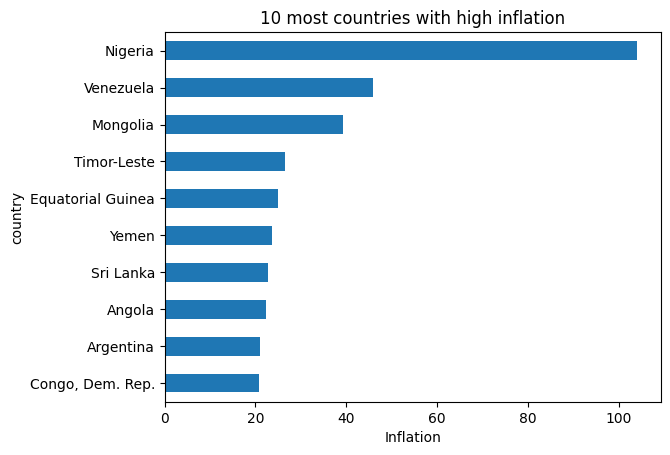

In [90]:
ax = data["inflation"].sort_values(ascending=False)[:10].plot(kind="barh")
ax.set_xlabel("Inflation")
ax.set_title("10 most countries with high inflation")
ax.invert_yaxis()

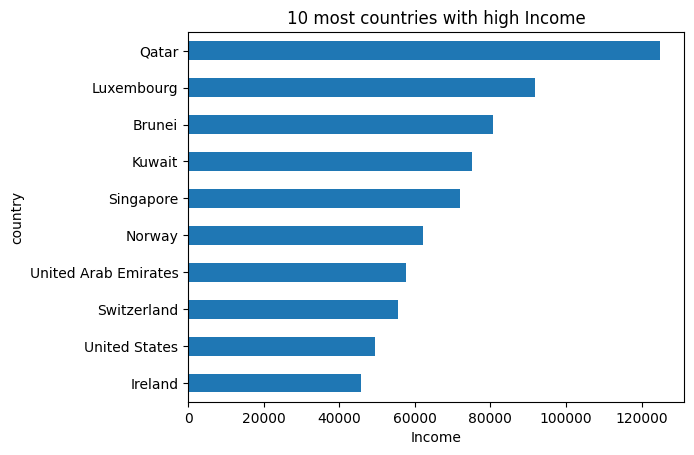

In [91]:
ax = data["income"].sort_values(ascending=False)[:10].plot(kind="barh")
ax.set_xlabel("Income")
ax.set_title("10 most countries with high Income")
ax.invert_yaxis()

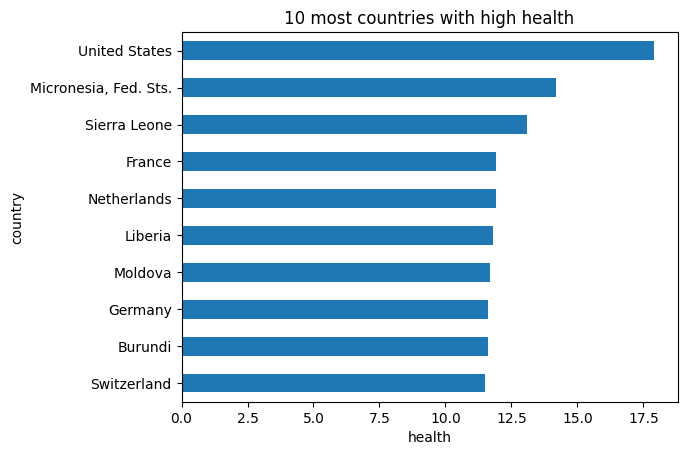

In [92]:
ax = data["health"].sort_values(ascending=False)[:10].plot(kind="barh")
ax.set_xlabel("health")
ax.set_title("10 most countries with high health")
ax.invert_yaxis()


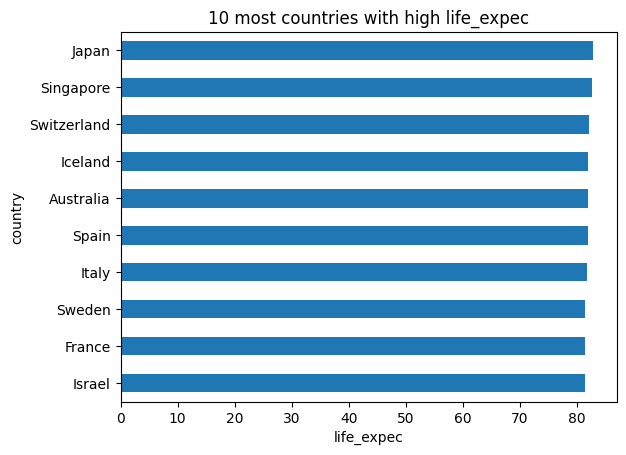

In [93]:
ax = data["life_expec"].sort_values(ascending=False)[:10].plot(kind="barh")
ax.set_xlabel("life_expec")
ax.set_title("10 most countries with high life_expec")
ax.invert_yaxis()

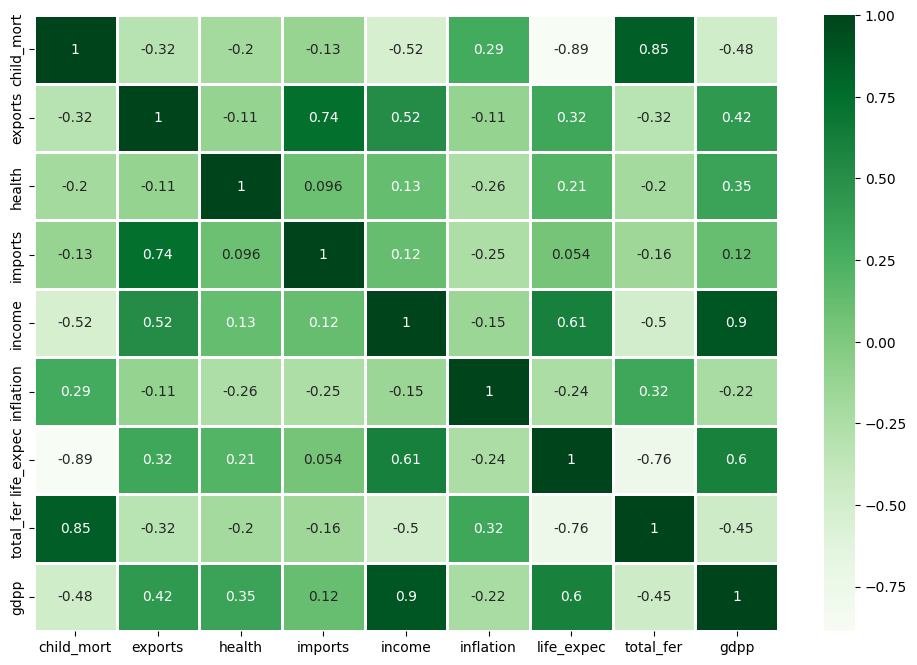

In [94]:
# Keep only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(numeric_data.corr(),
            annot=True,
            cmap="Greens",
            linewidths=1,
            ax=ax)
plt.show()


Feature Engineering:-Feature Engineering was performed to prepare the dataset for machine learning and clustering algorithms by selecting relevant features, removing unnecessary attributes, and transforming the data into a suitable format for analysis.

In [95]:
health_data = np.array(
                        (data['child_mort'] / data['child_mort'].mean()) +
                        (data['health'] / data['health'].mean()) +
                        (data['life_expec'] / data['life_expec'].mean()) +
                        (data['total_fer'] / data['total_fer'].mean())
                      ).reshape(-1,1)

trade_data = np.array(
                        (data['imports'] / data['imports'].mean()) +
                        (data['exports'] / data['exports'].mean())
                      ).reshape(-1,1)

finance = np.array(
                        (data['income'] / data['income'].mean()) +
                        (data['inflation'] / data['inflation'].mean()) +
                        (data['gdpp'] / data['gdpp'].mean())
                    ).reshape(-1,1)

data1 = pd.DataFrame(data = np.concatenate([health_data,trade_data,finance], axis = 1), index = data.index)
data1.columns = ["Health", "Trade", "Finance"]
data1.head()

,Health,Trade,Finance
country,,,
Afghanistan,6.239852,1.200812,1.349645
Albania,3.035901,1.717580,1.471658
Algeria,3.389763,1.603752,3.165367
Angola,6.469020,2.430387,3.494919
Antigua and Barbuda,2.964898,2.362940,2.240150


Scaling:-Feature scaling was performed to normalize the range of independent variables so that all features contribute equally to the machine learning and clustering algorithms.

In [96]:
from sklearn.preprocessing import StandardScaler

# Select only numeric columns
numeric_data = data.select_dtypes(include=[np.number])

# Scale numeric features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(numeric_data)

# Convert back to DataFrame for readability
data_scaled_df = pd.DataFrame(data_scaled, 
                              columns=numeric_data.columns, 
                              index=data.index)

data_scaled_df.head()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
Albania,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
Algeria,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
Angola,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
Antigua and Barbuda,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


Clustring Countries:-The goal of clustering is to segment countries into meaningful groups based on socio-economic and health indicators. This helps identify patterns such as developed, developing, and underdeveloped countries for targeted analysis and decision-making.

K-Means

Text(0.5, 1.0, 'K-Means Clustering')

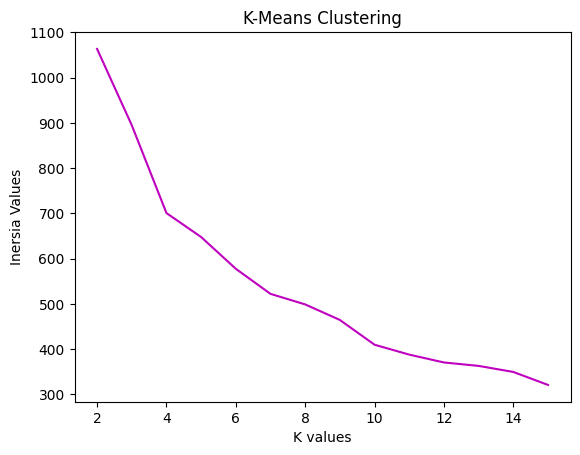

In [97]:
inersia_values = []

for k in np.arange(2,16):
    kmeans = KMeans(n_clusters = k,n_init='auto',random_state = 0).fit(data_scaled)
    inersia_values.append(kmeans.inertia_)


fig , ax = plt.subplots()
ax.plot(np.arange(2,16), inersia_values, color = "m")
ax.set_xlabel("K values")
ax.set_ylabel("Inersia Values")
ax.set_title("K-Means Clustering")

Text(0.5, 1.0, 'Silhouette Analysis for K-Means')

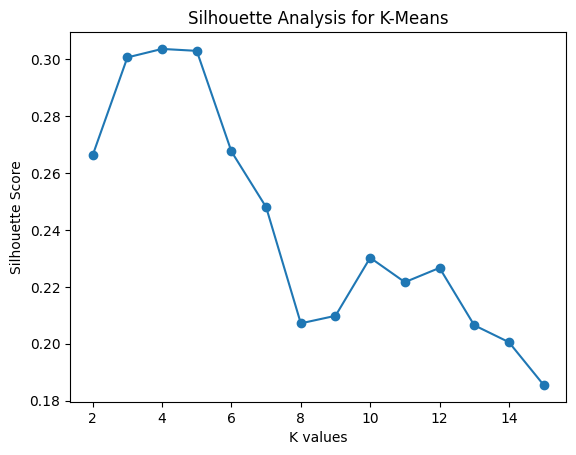

In [98]:
silhouette_values = []

K_range = np.arange(2, 16)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        n_init="auto",
        random_state=0
    )
    labels = kmeans.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    silhouette_values.append(score)

fig, ax = plt.subplots()
ax.plot(K_range, silhouette_values, marker="o")
ax.set_xlabel("K values")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Analysis for K-Means")

In [99]:
k_means_best = KMeans(n_clusters = 4,
                      n_init='auto',
                      random_state = 0).fit(data_scaled)

labels_kmeans = k_means_best.labels_
labels_kmeans

array([3, 1, 1, 3, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 3, 1, 1, 1, 3,
       1, 2, 1, 3, 3, 1, 3, 2, 1, 3, 3, 1, 1, 1, 3, 3, 3, 1, 3, 1, 2, 1,
       2, 1, 1, 1, 1, 3, 3, 1, 1, 2, 2, 3, 3, 1, 2, 3, 2, 1, 1, 3, 3, 1,
       3, 1, 2, 1, 1, 1, 3, 2, 2, 2, 1, 2, 1, 1, 3, 3, 2, 1, 3, 1, 1, 3,
       3, 1, 1, 0, 1, 3, 3, 1, 1, 3, 0, 3, 1, 1, 1, 1, 1, 1, 3, 3, 3, 1,
       2, 2, 3, 3, 2, 1, 3, 1, 1, 1, 1, 1, 2, 2, 1, 1, 3, 1, 1, 3, 1, 1,
       3, 0, 1, 2, 1, 3, 1, 2, 1, 1, 3, 1, 2, 2, 1, 3, 1, 3, 3, 1, 1, 1,
       1, 3, 1, 2, 2, 2, 1, 1, 1, 1, 1, 3, 3], dtype=int32)

<Axes: >

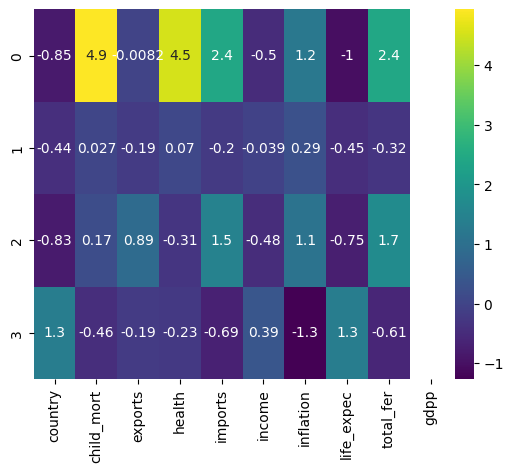

In [100]:
sns.heatmap(k_means_best.cluster_centers_,xticklabels=data.columns, cmap="viridis", annot=True)

Cluster 0: Economically Active but Health-Underprioritized Systems

Economically strong countries with active trade and income growth, but healthcare outcomes and investments lag behind economic progress.

Cluster 1: Structurally Vulnerable Health Systems

Countries with limited economic resources and weak healthcare infrastructure, facing significant development and health challenges.

Cluster 2: Financially Resourced but Health-Limited Systems

Countries with strong financial capacity but comparatively underdeveloped healthcare systems and outcomes.

Cluster 3: Health-Centered Service Systems

Countries that prioritize healthcare and social services despite lower economic and trade activity, achieving relatively better health outcomes.

In [101]:
data[labels_kmeans == 0]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,,
Luxembourg,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000
Malta,Malta,6.8,153.0,8.65,154.0,28300,3.830,80.3,1.36,21100
Singapore,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600


In [102]:
print("K-means Silhouette Score:",silhouette_score(data_scaled, labels_kmeans).__round__(3))

K-means Silhouette Score: 0.304


In [103]:
data["Cluster"] = labels_kmeans
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
country,,,,,,,,,,,
Afghanistan,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,3
Albania,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
Algeria,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
Angola,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,3
Antigua and Barbuda,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


In [104]:
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
country,,,,,,,,,,,
Afghanistan,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,3
Albania,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
Algeria,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
Angola,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,3
Antigua and Barbuda,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


In [105]:
data[data.index == "Iran"]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
country,,,,,,,,,,,
Iran,Iran,19.3,24.4,5.6,19.4,17400,15.9,74.5,1.76,6530,1


DBSCAN is an unsupervised machine learning clustering algorithm that groups data points based on density. It can identify clusters of arbitrary shapes and detect outliers (noise) automatically.

In [106]:
eps_values = np.arange(0.2, 3.0, 0.1)
min_samples_values = range(3, 15)

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(data_scaled)

        # Ignore cases with only noise or one cluster
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters < 2:
            continue

        score = silhouette_score(
            data_scaled[labels != -1],
            labels[labels != -1]
        )
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "silhouette": score
        })
 
results_df = pd.DataFrame(results)
best = results_df.sort_values(
    by="silhouette",
    ascending=False)
best.head()

,eps,min_samples,n_clusters,silhouette
2,0.7,4,2,0.756833
11,0.9,8,2,0.653254
18,1.0,9,2,0.556599
0,0.6,3,3,0.518930
27,1.1,11,2,0.510837


Display Dataset Overview:
To inspect the first few rows of the dataset and understand the available columns, we use:

In [107]:
print(data.head())
print(data.columns.tolist())

                                 country  child_mort  exports  health  \
country                                                                 
Afghanistan                  Afghanistan        90.2     10.0    7.58   
Albania                          Albania        16.6     28.0    6.55   
Algeria                          Algeria        27.3     38.4    4.17   
Angola                            Angola       119.0     62.3    2.85   
Antigua and Barbuda  Antigua and Barbuda        10.3     45.5    6.03   

                     imports  income  inflation  life_expec  total_fer   gdpp  \
country                                                                         
Afghanistan             44.9    1610       9.44        56.2       5.82    553   
Albania                 48.6    9930       4.49        76.3       1.65   4090   
Algeria                 31.4   12900      16.10        76.5       2.89   4460   
Angola                  42.9    5900      22.40        60.1       6.16   3530   
An

In [108]:
data.rename(columns={'Cluster': 'cluster'}, inplace=True)

Defining Features (X) and Target (y)

In [109]:
X = data.drop(['country', 'cluster'], axis=1)
y = data['cluster']

To evaluate the model properly, the dataset is split into training and testing sets:

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Random Forest Model Training

In [111]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

Random Forest Prediction

In [112]:
y_pred = rf_model.predict(X_test)
print(y_pred)

[1 1 2 1 3 3 3 1 1 1 1 3 3 2 1 2 1 3 1 1 3 2 1 1 1 2 2 3 2 1 1 1 3 1]


XGBoost Classification Model

In [113]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='multi:softmax',
    num_class=4
)

In [114]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=4, ...)

XGBoost Prediction

In [115]:
y_pred = xgb_model.predict(X_test)
print(y_pred)

[1 1 2 1 3 3 3 1 1 1 1 3 3 2 1 2 1 3 1 1 3 2 1 1 1 2 2 3 2 1 1 1 3 1]


In [116]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9411764705882353


Model Evaluation


In [117]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9411764705882353

Classification Report:
               precision    recall  f1-score   support

           1       0.94      0.94      0.94        18
           2       0.86      1.00      0.92         6
           3       1.00      0.90      0.95        10

    accuracy                           0.94        34
   macro avg       0.93      0.95      0.94        34
weighted avg       0.95      0.94      0.94        34



Feature Importance Analysis


In [118]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

      Feature  Importance
0  child_mort    0.296873
6  life_expec    0.195815
8        gdpp    0.189217
7   total_fer    0.123444
4      income    0.097615
2      health    0.033844
1     exports    0.029948
3     imports    0.024741
5   inflation    0.008503


# Country Intelligence System using Classification, Ensemble Learning and Clustering

## Project Objective

The primary objective of this project is to identify countries that require humanitarian assistance by analyzing socio-economic and health-related indicators. Machine learning techniques are utilized to segment countries, uncover hidden patterns, and generate data-driven recommendations for effective aid allocation.

**Libraries Used:** Pandas, NumPy

## Data Collection and Understanding

The dataset consists of multiple socio-economic and health indicators, including income, GDP per capita, child mortality rate, life expectancy, inflation, exports, imports, and healthcare expenditure. These variables collectively represent the overall development status of each country.

**Libraries Used:** Pandas

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is conducted to understand the distribution of features, identify potential anomalies, and gain meaningful insights from the dataset. This step helps establish a strong foundation for subsequent modeling activities.

**Libraries Used:** Pandas, Matplotlib, Seaborn

## Data Preprocessing

Data preprocessing involves cleaning the dataset, handling missing values, selecting relevant features, and preparing the data for machine learning algorithms. Proper preprocessing ensures reliable and accurate model performance.

**Libraries Used:** Pandas, NumPy, Scikit-learn

## Feature Scaling

Feature scaling is performed using StandardScaler to normalize all variables to a common scale. This prevents features with larger numerical ranges from disproportionately influencing clustering and classification algorithms.

**Libraries Used:** Scikit-learn (StandardScaler)

## Optimal Cluster Selection

The Elbow Method is employed to determine the optimal number of clusters. This technique evaluates clustering performance across multiple cluster counts and identifies the most suitable segmentation structure.

**Libraries Used:** Scikit-learn, Matplotlib

## K-Means Clustering

K-Means clustering is applied to group countries with similar socio-economic characteristics. The generated clusters represent different development categories, ranging from highly developed to underdeveloped nations.

**Libraries Used:** Scikit-learn (KMeans)

## Cluster Validation

The Silhouette Score is used to evaluate the quality of clustering results. It measures how well-separated and cohesive the clusters are, providing an indication of clustering effectiveness.

**Libraries Used:** Scikit-learn (silhouette_score)

## DBSCAN Clustering

DBSCAN is implemented as a density-based clustering technique to identify naturally occurring groups and detect outlier countries. This approach complements K-Means by handling non-spherical cluster structures.

**Libraries Used:** Scikit-learn (DBSCAN)

## Dimensionality Reduction and Visualization

Principal Component Analysis (PCA) is utilized to reduce data dimensionality and visualize country clusters in a two-dimensional space. This enables easier interpretation of segmentation patterns.

**Libraries Used:** Scikit-learn (PCA), Matplotlib, Seaborn

## Label Generation for Classification

The cluster assignments obtained from K-Means are transformed into target labels. These labels enable the development of supervised classification models for predicting country categories.

**Libraries Used:** Pandas, NumPy

## Random Forest Classification

A Random Forest classifier is trained to predict cluster membership based on socio-economic indicators. By combining multiple decision trees, the model improves prediction accuracy and reduces overfitting.

**Libraries Used:** Scikit-learn (RandomForestClassifier)

## XGBoost Classification

An XGBoost classifier is developed to further enhance predictive performance. This advanced boosting algorithm iteratively improves model accuracy by minimizing classification errors.

**Libraries Used:** XGBoost (XGBClassifier)

## Model Evaluation

The classification models are evaluated using metrics such as Accuracy Score, Confusion Matrix, Precision, Recall, and F1-Score. These metrics provide a comprehensive assessment of predictive performance.

**Libraries Used:** Scikit-learn Metrics (accuracy_score, confusion_matrix, classification_report)

## Feature Importance Analysis

Feature importance analysis is conducted to identify the variables that have the greatest impact on country classification. This analysis provides valuable insights into key development indicators.

**Libraries Used:** Pandas, Random Forest Feature Importance, XGBoost Feature Importance

## Cluster Profiling

Each cluster is analyzed by examining average socio-economic and health characteristics. This profiling helps interpret the underlying differences between country groups.

**Libraries Used:** Pandas, NumPy

## Identification of High-Priority Countries

Countries belonging to the cluster characterized by low income, low GDP per capita, high child mortality, and low life expectancy are identified as high-priority candidates for humanitarian assistance.

**Libraries Used:** Pandas

## Business Impact

The proposed intelligence system enables data-driven decision-making by helping organizations allocate resources efficiently and prioritize countries with the greatest developmental needs.

## Conclusion

This project successfully integrates unsupervised learning, supervised learning, and ensemble techniques to generate actionable insights. The resulting Country Intelligence System supports strategic humanitarian planning and effective aid distribution.

## Libraries Used in Project

* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* XGBoost
